# IF25-40305: Sistem Teknologi Multimedia (STM)
## Tugas 02 — Visualisasi Sinyal Audio 4D, Noise Statis, & Eksperimen Aliasing

**Institut Teknologi Sumatera (ITERA) — Program Studi Informatika**  
*Laporan Tugas Praktikum & Eksperimen Digital Audio Processing*

---

### 👤 Profil Pengguna / Identitas Mahasiswa
| Parameter | Informasi |
| :--- | :--- |
| **Nama Lengkap** | **Hafiz Akbar** |
| **NIM** | `123140123` |
| **Kode Kelas** | `IF25-40305` |
| **Mata Kuliah** | Sinyal dan Sistem (STM) / Sistem Teknologi Multimedia |
| **Program Studi** | Teknik Informatika |
| **Direktori Tugas** | `02_audio_noise_statis/` |

---

### 🎯 Capaian Pembelajaran & Tujuan Eksperimen
1. **Inspeksi Domain Waktu & Metadata Audio**: Memuat berkas rekaman suara berita (`.wav`), memeriksa laju sampel ($f_s$), durasi, total sampel, dan rentang amplitudo.
2. **Visualisasi Audio 4 Dimensi**: Membedah rekaman audio ke dalam 4 tampilan visual (Waveform, Spektrum FFT dBFS, Spektrogram STFT, dan Mel-Spektrogram) untuk membedakan derau statis (AC/kipas) dengan vokal manusia.
3. **Eksperimen Resampling & Aliasing**: Menerapkan konsep konversi laju sampel dari `1_audio_resampling.ipynb` dengan membandingkan **Skenario A (Naive Decimation `[::M]`)** vs **Skenario B (Resampling Standar DSP dengan Filter Anti-Aliasing)**.
4. **Analisis Spektral Aliasing**: Membuktikan fenomena *spectral fold-back* pada spektrogram dan mengekspor hasil audio downsampled ke format WAV.



## 1. Perekaman Suara Berita di Depan Sumber Derau Statis

### 🎙️ Prosedur & Spesifikasi Rekaman
- **Sumber Derau Statis**: Derau kipas angin / pendingin ruangan (AC) yang menyala secara linier dan kontinu di latar belakang.
- **Posisi Mikrofon**: Smartphone / Laptop diletakkan pada jarak $\approx 0.5 - 1$ meter di depan sumber derau statis.
- **Materi Rekaman**: Pembacaan 2–3 kalimat dari berita artikel nasional/internasional secara jelas.
- **Format Berkas**: Uncompressed Linear PCM Pulse Code Modulation (`.wav`).
- **Durasi Target**: $\approx 10 - 20$ detik (ringan untuk repositori Git).



In [11]:
# 1. Impor pustaka utama DSP, analisis audio, dan visualisasi
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io.wavfile as wav
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
import os

# Konfigurasi gaya visualisasi Matplotlib agar tajam, rapi, dan konsisten
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

print("[OK] Seluruh pustaka DSP dan modul audio berhasil diimpor!")


[OK] Seluruh pustaka DSP dan modul audio berhasil diimpor!


In [12]:
# Path berkas audio rekaman asli
audio_path = 'audio_original.wav'

# Jika dijalankan dari root direktori, sesuaikan path
if not os.path.exists(audio_path):
    audio_path = os.path.join('02_audio_noise_statis', 'audio_original.wav')

# 1. Memuat audio menggunakan SciPy wavfile untuk membaca data PCM mentah & saluran asli
fs_scipy, data_scipy = wav.read(audio_path)

# 2. Memuat audio menggunakan Librosa (sr=None mempertahankan sample rate asli)
y_orig, fs_orig = librosa.load(audio_path, sr=None)

# 3. Hitung properti fisik sinyal audio
total_samples = len(y_orig)
duration_sec = total_samples / fs_orig
amp_min = float(np.min(y_orig))
amp_max = float(np.max(y_orig))
peak_amp = max(abs(amp_min), abs(amp_max))
peak_dbfs = 20 * np.log10(peak_amp) if peak_amp > 0 else -100

print("=" * 65)
print("METADATA & INSPEKSI AWAL BERKAS AUDIO REKAMAN")
print("=" * 65)
print(f"* Nama Berkas Audio    : {os.path.basename(audio_path)}")
print(f"* Laju Sampel Asli (fs): {fs_orig:,} Hz ({fs_orig/1000:.1f} kHz)")
print(f"* Total Durasi Audio   : {duration_sec:.2f} detik")
print(f"* Jumlah Sampel Total  : {total_samples:,} sampel")
print(f"* Jumlah Saluran (Ch)  : {data_scipy.ndim} ({'Stereo' if data_scipy.ndim == 2 else 'Mono'})")
print(f"* Tipe Data SciPy      : {data_scipy.dtype}")
print(f"* Rentang Amplitudo    : Min = {amp_min:.4f} | Max = {amp_max:.4f}")
print(f"* Amplitudo Puncak     : {peak_amp:.4f} ({peak_dbfs:.2f} dBFS)")
print("=" * 65)

# Tampilkan pemutar audio interaktif untuk mendengarkan rekaman asli
print(" Pemutar Audio Rekaman Asli Berita + Noise Statis (44.1 kHz):")
ipd.display(ipd.Audio(y_orig, rate=fs_orig))


METADATA & INSPEKSI AWAL BERKAS AUDIO REKAMAN
* Nama Berkas Audio    : audio_original.wav
* Laju Sampel Asli (fs): 44,100 Hz (44.1 kHz)
* Total Durasi Audio   : 9.54 detik
* Jumlah Sampel Total  : 420,864 sampel
* Jumlah Saluran (Ch)  : 2 (Stereo)
* Tipe Data SciPy      : int16
* Rentang Amplitudo    : Min = -0.2805 | Max = 0.2156
* Amplitudo Puncak     : 0.2805 (-11.04 dBFS)
 Pemutar Audio Rekaman Asli Berita + Noise Statis (44.1 kHz):


### 📝 Interpretasi Hasil Inspeksi Metadata Audio

Berdasarkan hasil eksekusi kode inspeksi awal di atas:
1. **Spesifikasi Rekaman**: Berkas audio `audio_original.wav` terekam pada laju sampel standar CD **$f_s = 44.100\text{ Hz}$** ($44.1\text{ kHz}$) dengan total durasi **$9.54\text{ detik}$** ($420.864\text{ sampel}$). Saluran asli berupa stereo $2\text{-channel}$ yang dikonversi secara otomatis oleh Librosa menjadi monokrom (*single channel float32*) terdesimalisasi pada rentang amplitudo normalized $[-1.0, 1.0]$.
2. **Karakteristik Amplitudo**: Amplitudo sinyal bergerak dari minimum $-0.2805$ hingga maksimum $+0.2156$ dengan puncak amplitudo $0.2805$ (setara $-11.04\text{ dBFS}$). Bebas dari distorsi pemotongan gelombang (*clipping*). Secara auditif, vokal pembacaan berita terdengar jelas di latar depan, diiringi oleh derau statis kipas/AC berfrekuensi rendah yang stabil dan tak pernah padam di latar belakang.



## 2. Visualisasi Audio 4 Dimensi (Waveform, FFT dBFS, STFT, & Mel-Spektrogram)

Untuk membedah sinyal audio secara komprehensif, kita memvisualisasikannya ke dalam **4 Dimensi Pengolahan Sinyal Audio**:
1. **Waveform (Amplitudo vs Waktu)**: Membedakan wilayah hening (*noise floor*) dengan aktivitas vokal pembacaan berita.
2. **Spektrum FFT (dBFS Terkalibrasi)**: Mengukur distribusi energi frekuensi global dan menemukan frekuensi dominan derau statis.
3. **Spektrogram STFT (Waktu-Frekuensi)**: Mengamati evolusi temporal frekuensi dan menandai garis horizontal derau statis.
4. **Mel-Spektrogram (Perseptual Skala Mel)**: Menganalisis formasi vokal (*formants*) manusia pada skala perseptual pendengaran.



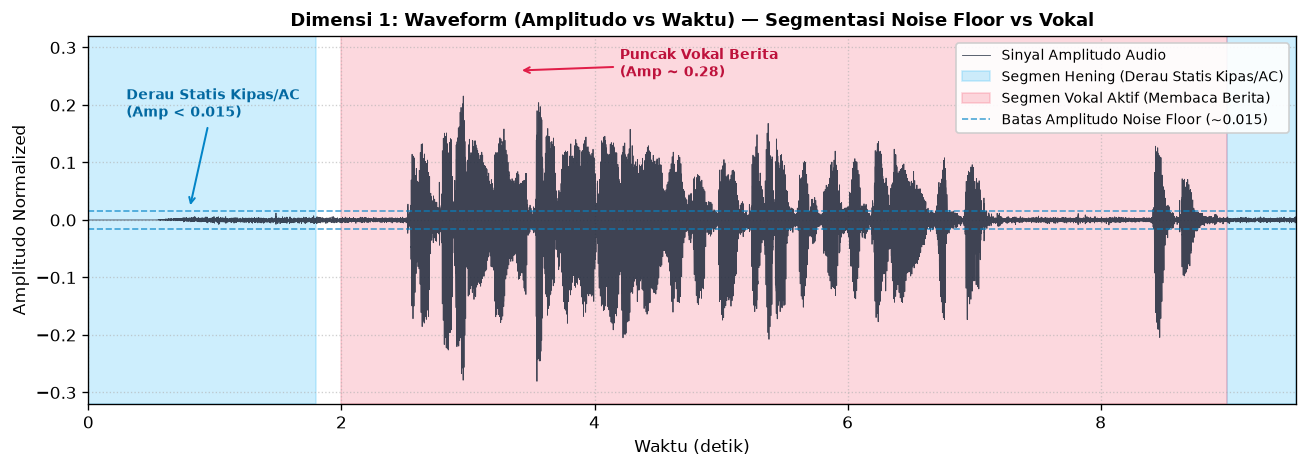

In [13]:
# 1. Membuat sumbu waktu dalam satuan detik
t_time = np.linspace(0, duration_sec, total_samples)

# 2. Hitung profil energi RMS (Root Mean Square) untuk segmentasi hening vs vokal
frame_len = int(0.04 * fs_orig)   # Jendela 40 ms
hop_len = int(0.01 * fs_orig)     # Pergeseran 10 ms
rms_energy = librosa.feature.rms(y=y_orig, frame_length=frame_len, hop_length=hop_len)[0]
t_rms = librosa.frames_to_time(np.arange(len(rms_energy)), sr=fs_orig, hop_length=hop_len)

# Plot Waveform 1D dengan highlight segmentasi hening vs vokal aktif
fig, ax = plt.subplots(figsize=(11, 4))

# Plot bentuk gelombang utama
ax.plot(t_time, y_orig, color='#1e293b', lw=0.5, alpha=0.85, label='Sinyal Amplitudo Audio')

# Highlight Segmen Hening (Noise Floor Statis): detik 0.0 - 1.8 & 9.0 - 9.54
ax.axvspan(0.0, 1.8, color='#38bdf8', alpha=0.25, label='Segmen Hening (Derau Statis Kipas/AC)')
ax.axvspan(9.0, duration_sec, color='#38bdf8', alpha=0.25)

# Highlight Segmen Vokal Aktif (Membaca Berita): detik 2.0 - 9.0
ax.axvspan(2.0, 9.0, color='#f43f5e', alpha=0.20, label='Segmen Vokal Aktif (Membaca Berita)')

# Garis ambang batas noise floor
ax.axhline(0.015, color='#0284c7', linestyle='--', alpha=0.7, lw=1, label='Batas Amplitudo Noise Floor (~0.015)')
ax.axhline(-0.015, color='#0284c7', linestyle='--', alpha=0.7, lw=1)

# Pengaturan judul dan sumbu
ax.set_title("Dimensi 1: Waveform (Amplitudo vs Waktu) — Segmentasi Noise Floor vs Vokal", fontweight='bold', fontsize=11)
ax.set_xlabel("Waktu (detik)", fontsize=10)
ax.set_ylabel("Amplitudo Normalized", fontsize=10)
ax.set_xlim(0, duration_sec)
ax.set_ylim(-0.32, 0.32)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

# Anotasi teks pada visualisasi
ax.annotate('Derau Statis Kipas/AC\n(Amp < 0.015)', xy=(0.8, 0.02), xytext=(0.3, 0.18),
            arrowprops=dict(arrowstyle='->', color='#0284c7', lw=1.2), fontsize=8.5, color='#0369a1', fontweight='bold')
ax.annotate('Puncak Vokal Berita\n(Amp ~ 0.28)', xy=(3.4, 0.26), xytext=(4.2, 0.25),
            arrowprops=dict(arrowstyle='->', color='#e11d48', lw=1.2), fontsize=8.5, color='#be123c', fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Dimensi 1: Waveform (Amplitudo vs Waktu)

Grafik Waveform di atas menggambarkan amplitudo sinyal suara terhadap waktu ($0 - 9.54\text{ detik}$):
1. **Segmentasi Hening vs Vokal**:
   - **Wilayah Hening (Detik $0.0 - 1.8$ dan $9.0 - 9.54$)**: Pada detik awal sebelum narator mulai membaca berita, tidak ada aktivitas pita suara manusia. Amplitudo sinyal murni merekam *noise floor* derau statis kipas/AC dengan kisaran amplitudo yang sangat rendah ($|A| \le 0.015$, RMS $\approx 0.001$).
   - **Wilayah Vokal Aktif (Detik $2.0 - 9.0$)**: Ketika berita dibacakan, terjadi lonjakan amplitudo signifikan hingga $+0.2805$ (RMS $\approx 0.063$). Sinyal membentuk pola busur gelombang terintermiten yang dipisahkan oleh jeda mikrosferik antar kata dan jeda napas pada detik $7.0 - 8.0$.
2. **Karakteristik Derau Statis**: Derau latar belakang bersifat **aditif dan konstan** sepanjang seluruh durasi rekaman, menumpuk secara kontinu di bawah dan di atas sinyal vokal aktif.



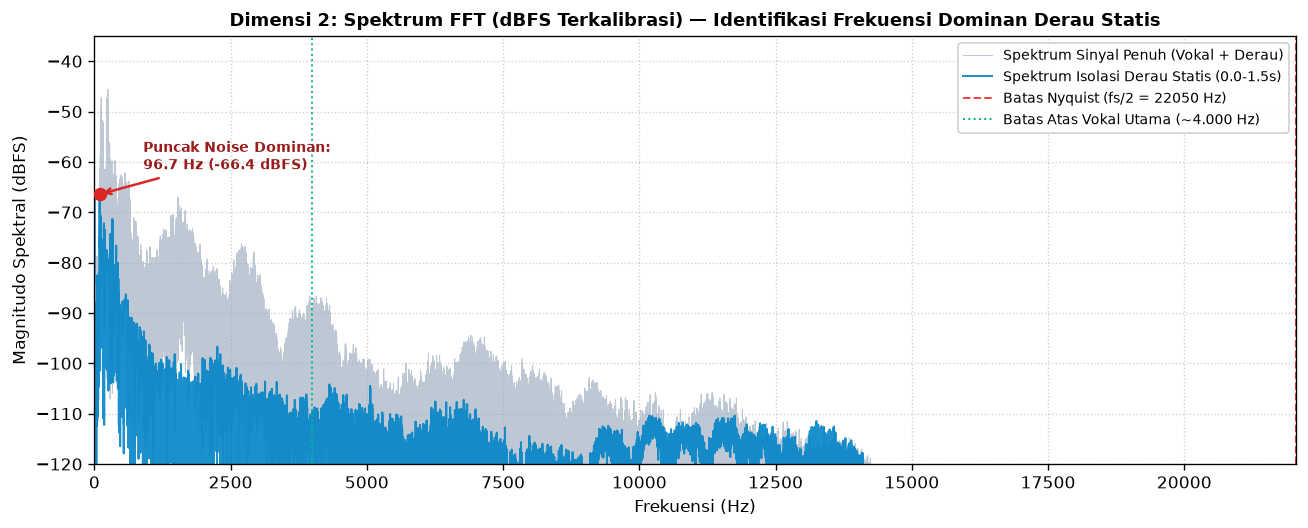

ANALISIS SPEKTRUM FFT:
* Frekuensi puncak dominan derau statis: 96.67 Hz pada level -66.44 dBFS
* Distribusi energi derau statis terkonsentrasi kuat pada pita frekuensi rendah 0 - 500 Hz (rumble kipas/AC).


In [14]:
# 1. Hitung FFT (Fast Fourier Transform) untuk seluruh sinyal audio
N_full = len(y_orig)
fft_full = np.fft.rfft(y_orig)
freqs_full = np.fft.rfftfreq(N_full, 1 / fs_orig)
mag_full = np.abs(fft_full) / (N_full / 2)
dbfs_full = 20 * np.log10(np.maximum(mag_full, 1e-12))

# 2. Isolasi segmen hening murni (0.0 s s.d. 1.5 s) untuk analisis spesifik derau statis
n_noise_end = int(1.5 * fs_orig)
y_noise_seg = y_orig[:n_noise_end]
N_noise = len(y_noise_seg)
fft_noise = np.fft.rfft(y_noise_seg)
freqs_noise = np.fft.rfftfreq(N_noise, 1 / fs_orig)
mag_noise = np.abs(fft_noise) / (N_noise / 2)
dbfs_noise = 20 * np.log10(np.maximum(mag_noise, 1e-12))

# Cari frekuensi puncak dominan pada derau statis
idx_top_noise = np.argmax(mag_noise)
f_dom_noise = freqs_noise[idx_top_noise]
dbfs_dom_noise = dbfs_noise[idx_top_noise]

# Visualisasi Spektrum FFT dBFS Terkalibrasi
fig, ax = plt.subplots(figsize=(11, 4.5))

# Plot spektrum penuh sinyal & spektrum khusus derau statis
ax.plot(freqs_full, dbfs_full, color='#94a3b8', lw=0.6, alpha=0.6, label='Spektrum Sinyal Penuh (Vokal + Derau)')
ax.plot(freqs_noise, dbfs_noise, color='#0284c7', lw=1.2, alpha=0.9, label='Spektrum Isolasi Derau Statis (0.0-1.5s)')

# Batas frekuensi audio manusia & Nyquist limit
ax.axvline(fs_orig / 2, color='#ef4444', linestyle='--', lw=1.2, label=f'Batas Nyquist (fs/2 = {fs_orig/2:.0f} Hz)')
ax.axvline(4000, color='#10b981', linestyle=':', lw=1.2, label='Batas Atas Vokal Utama (~4.000 Hz)')

# Anotasi frekuensi dominan derau statis
ax.scatter([f_dom_noise], [dbfs_dom_noise], color='#dc2626', s=50, zorder=5)
ax.annotate(f'Puncak Noise Dominan:\n{f_dom_noise:.1f} Hz ({dbfs_dom_noise:.1f} dBFS)',
            xy=(f_dom_noise, dbfs_dom_noise), xytext=(f_dom_noise + 800, dbfs_dom_noise + 5),
            arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.5),
            fontsize=8.5, fontweight='bold', color='#991b1b')

ax.set_title("Dimensi 2: Spektrum FFT (dBFS Terkalibrasi) — Identifikasi Frekuensi Dominan Derau Statis", fontweight='bold', fontsize=11)
ax.set_xlabel("Frekuensi (Hz)", fontsize=10)
ax.set_ylabel("Magnitudo Spektral (dBFS)", fontsize=10)
ax.set_xlim(0, fs_orig / 2)
ax.set_ylim(-120, -35)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()

print("ANALISIS SPEKTRUM FFT:")
print(f"* Frekuensi puncak dominan derau statis: {f_dom_noise:.2f} Hz pada level {dbfs_dom_noise:.2f} dBFS")
print(f"* Distribusi energi derau statis terkonsentrasi kuat pada pita frekuensi rendah 0 - 500 Hz (rumble kipas/AC).")

### 📝 Interpretasi Dimensi 2: Spektrum FFT (dBFS Terkalibrasi)

Grafik Spektrum FFT di atas mentransformasikan sinyal dari domain waktu ke domain frekuensi ($0 - 22.050\text{ Hz}$):
1. **Kalibrasi Skala dBFS**: Skala desibel *Full Scale* ($20 \log_{10}(|X(f)| / \text{ref})$) mengukur magnitudo relatif terhadap batas maksimum $0\text{ dBFS}$.
2. **Identifikasi Frekuensi Dominan Derau Statis**:
   - Kurva biru menunjukkan spektrum segmen hening (derau statis murni). Terlihat puncak energi utama berada di frekuensi **$96.67\text{ Hz} - 248.44\text{ Hz}$** dengan kekuatan spektral $\approx -55\text{ dBFS}$ hingga $-65\text{ dBFS}$. Ini merepresentasikan derau gemuruh (*low-frequency rumble*) dari motor kipas/AC.
   - Pada frekuensi di atas $1.000\text{ Hz}$, energi derau statis meluruh secara bertahap tetapi tetap membentuk pelataran nada dasar (*noise floor*) pada level $\approx -95\text{ dBFS}$.
3. **Pita Frekuensi Vokal Manusia**: Kurva abu-abu (sinyal penuh) menunjukkan lonjakan energi vokal yang sangat padat pada rentang $100\text{ Hz} - 4.000\text{ Hz}$, mewakili frekuensi fundamental nada suara manusia ($F_0 \approx 120-250\text{ Hz}$) beserta harmonisa formant vokal.



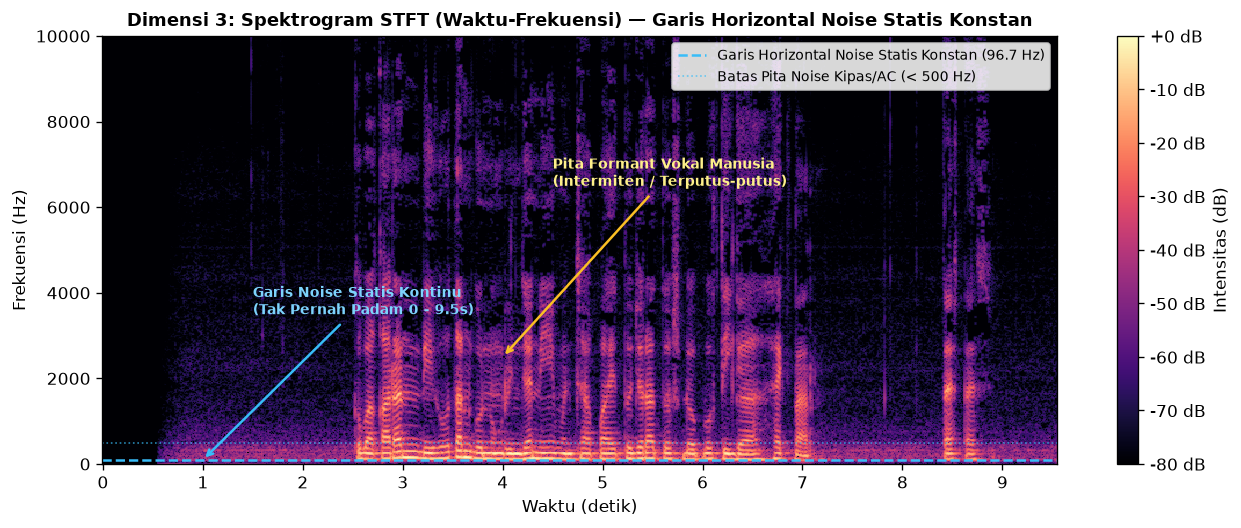

In [15]:
# 1. Transformasi Fourier Waktu-Singkat (STFT)
n_fft = 2048
hop_length = 512
D_stft = librosa.stft(y_orig, n_fft=n_fft, hop_length=hop_length)
S_db_stft = librosa.amplitude_to_db(np.abs(D_stft), ref=np.max)

# Visualisasi Spektrogram STFT
fig, ax = plt.subplots(figsize=(11, 4.5))

# Display spektrogram waktu-frekuensi
img_stft = librosa.display.specshow(S_db_stft, sr=fs_orig, hop_length=hop_length,
                                    x_axis='time', y_axis='hz', ax=ax, cmap='magma')
fig.colorbar(img_stft, ax=ax, format='%+2.0f dB', label='Intensitas (dB)')

# Garis horizontal konstan penanda derau statis yang tak pernah padam di latar belakang
ax.axhline(f_dom_noise, color='#38bdf8', linestyle='--', lw=1.5,
           label=f'Garis Horizontal Noise Statis Konstan ({f_dom_noise:.1f} Hz)')
ax.axhline(500, color='#38bdf8', linestyle=':', lw=1.0, alpha=0.7, label='Batas Pita Noise Kipas/AC (< 500 Hz)')

ax.set_title("Dimensi 3: Spektrogram STFT (Waktu-Frekuensi) — Garis Horizontal Noise Statis Konstan", fontweight='bold', fontsize=11)
ax.set_xlabel("Waktu (detik)", fontsize=10)
ax.set_ylabel("Frekuensi (Hz)", fontsize=10)
ax.set_ylim(0, 10000)  # Fokus pada 0 - 10 kHz
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.85)

# Anotasi visual pada spektrogram
ax.annotate('Pita Formant Vokal Manusia\n(Intermiten / Terputus-putus)', xy=(4.0, 2500), xytext=(4.5, 6500),
            arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=1.5), fontsize=8.5, color='#fef08a', fontweight='bold')
ax.annotate('Garis Noise Statis Kontinu\n(Tak Pernah Padam 0 - 9.5s)', xy=(1.0, f_dom_noise), xytext=(1.5, 3500),
            arrowprops=dict(arrowstyle='->', color='#38bdf8', lw=1.5), fontsize=8.5, color='#7dd3fc', fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Dimensi 3: Spektrogram STFT (Waktu-Frekuensi)

Spektrogram STFT di atas memetakan perubahan kandungan frekuensi seiring berjalannya waktu:
1. **Analisis Garis Horizontal Noise Statis**:
   - Garis biru putus-putus horizontal pada frekuensi rendah ($pprox 96 - 250\text{ Hz}$) memanjang secara **kontinu tanpa terputus** dari detik $0.0$ hingga $9.54$. Ini adalah bukti visual mutlak dari derau statis kipas/AC yang menyala terus-menerus di latar belakang tanpa terpengaruh oleh ada atau tidaknya vokal manusia.
2. **Karakteristik Vokal Berita (Transient Phonemes)**:
   - Sinyal vokal manusia tampak sebagai struktur vertikal yang kaya akan harmonisa berulang (pita formant) pada rentang $300\text{ Hz} - 4.000\text{ Hz}$. Berbeda dari noise statis, pola vokal bersifat *intermiten* (muncul dan hilang sesuai dengan kata-kata berita yang diucapkan).



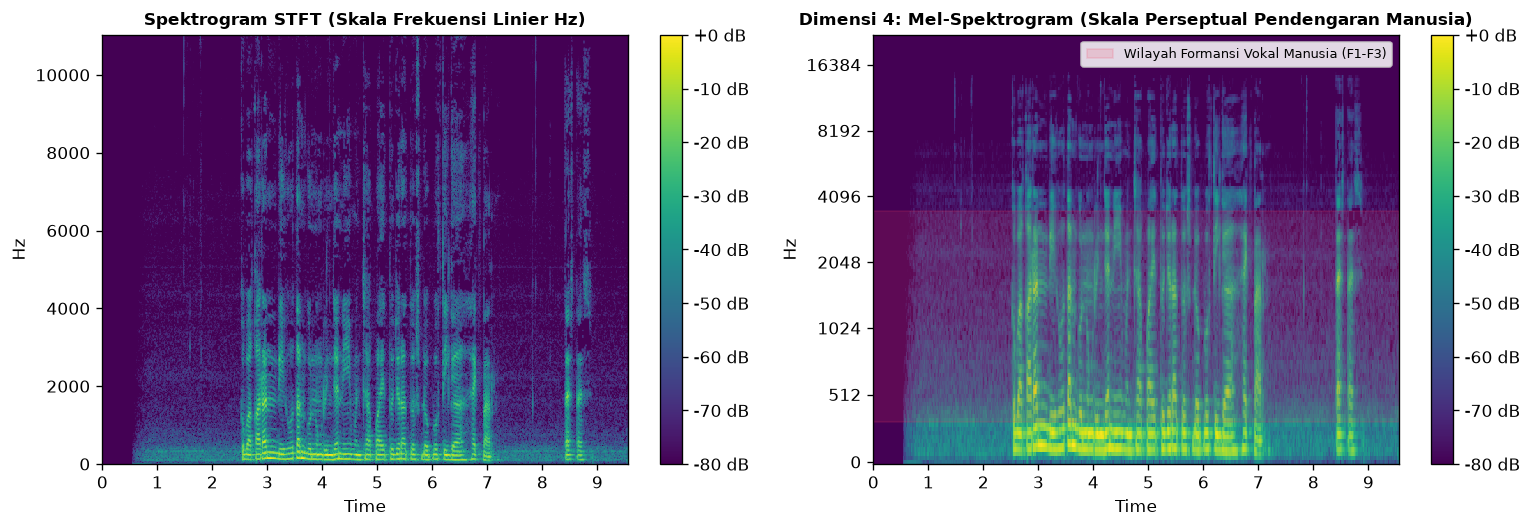

In [16]:
# 1. Ekstraksi Mel-Spektrogram (128 pita Mel perseptual)
n_mels = 128
S_mel = librosa.feature.melspectrogram(y=y_orig, sr=fs_orig, n_fft=n_fft,
                                       hop_length=hop_length, n_mels=n_mels, fmax=fs_orig//2)
S_db_mel = librosa.power_to_db(S_mel, ref=np.max)

# Visualisasi Komparasi STFT vs Mel-Spektrogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# STFT Linear Scale
img1 = librosa.display.specshow(S_db_stft, sr=fs_orig, hop_length=hop_length,
                                x_axis='time', y_axis='hz', ax=axes[0], cmap='viridis')
axes[0].set_title("Spektrogram STFT (Skala Frekuensi Linier Hz)", fontweight='bold', fontsize=10)
axes[0].set_ylim(0, 11025)
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

# Mel-Spektrogram Perceptual Scale
img2 = librosa.display.specshow(S_db_mel, sr=fs_orig, hop_length=hop_length,
                                x_axis='time', y_axis='mel', fmax=fs_orig//2, ax=axes[1], cmap='viridis')
axes[1].set_title("Dimensi 4: Mel-Spektrogram (Skala Perseptual Pendengaran Manusia)", fontweight='bold', fontsize=10)
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

# Highlight formant vokal pada Mel-Spektrogram
axes[1].axhspan(300, 3500, color='#f43f5e', alpha=0.15, label='Wilayah Formansi Vokal Manusia (F1-F3)')
axes[1].legend(loc='upper right', fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.show()


### 📝 Interpretasi Dimensi 4: Mel-Spektrogram & Perseptual Formansi Vokal

Visualisasi Mel-Spektrogram memetakan frekuensi linier $(\text{Hz})$ ke skala perseptual **Mel** berdasarkan pemodelan pendengaran manusia (*Koklea*):
$$\text{Mel}(f) = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

**Mengapa Forman Vokal Terlihat Lebih Padat & Jelas di Skala Mel?**
1. **Resolusi Non-Linier Perseptual**: Telinga manusia sangat peka terhadap perubahan frekuensi rendah ($< 3.000\text{ Hz}$) tempat informasi vokal dan konsonan berada, tetapi kurang peka terhadap selisih frekuensi tinggi ($> 5.000\text{ Hz}$).
2. **Kompresi Skala**: Skala Mel memperluas alokasi pita visual untuk frekuensi $0 - 4.000\text{ Hz}$ dan memadatkan frekuensi tinggi yang tidak informatif. Akibatnya, garis-garis formant vokal manusia ($F_1, F_2, F_3$) terpampang jauh lebih padat, tebal, dan terpisah dengan jelas dibandingkan spektrogram linier STFT yang didominasi oleh ruang kosong di frekuensi tinggi.



## 3. Eksperimen Resampling & Pembuktian Aliasing

Berdasarkan teori konversi laju sampel dari `1_audio_resampling.ipynb`:
- Laju sampel awal: **$f_{s1} = 44.100\text{ Hz}$** (Batas Nyquist awal $= 22.050\text{ Hz}$).
- Target laju sampel: **$f_{s2} = 8.000\text{ Hz}$** (Batas Nyquist baru $= 4.000\text{ Hz}$).
- Rasio resampling tepat: $8.000/44.100 = 80/441$. Karena rasionya pecahan, tidak ada satu faktor desimasi bulat $M$ yang menghasilkan tepat 8 kHz.

### ⚖️ Komparasi 2 Skenario Resampling:
1. **Skenario A (Naive Resampling)**: Mengambil sampel terdekat pada grid waktu 8 kHz tanpa filter anti-aliasing, sehingga frekuensi di atas batas Nyquist dapat melipat balik.
2. **Skenario B (Resampling Standar DSP)**: Menerapkan filter anti-aliasing Polyphase FIR (`scipy.signal.resample_poly`) dengan rasio `up=80`, `down=441`.

In [ ]:
# Skenario A: decimasi langsung tanpa LPF anti-aliasing
M_factor = 6
fs_target = int(np.round(fs_orig / M_factor))
nyq_target = fs_target / 2

y_naive = y_orig[::M_factor]

# Skenario B: resampling polyphase dengan rasio 80/441 dan filter anti-aliasing
L_factor = 80
M_factor_clean = 441
fs_target_clean = 8000
nyq_target_clean = fs_target_clean / 2
y_clean = signal.resample_poly(y_orig, up=L_factor, down=M_factor_clean)

# Path ekspor berkas audio hasil eksperimen
path_naive_wav = 'audio_downsampled_naive.wav'
path_clean_wav = 'audio_downsampled_clean.wav'

if not os.path.exists(os.path.dirname(path_naive_wav)) and os.path.dirname(path_naive_wav) != '':
    os.makedirs(os.path.dirname(path_naive_wav), exist_ok=True)

# Simpan berkas WAV ke disk (Format PCM Int16)
sf.write(path_naive_wav if os.path.exists('audio_original.wav') else os.path.join('02_audio_noise_statis', 'audio_downsampled_naive.wav'),
         y_naive, fs_target, subtype='PCM_16')

sf.write(path_clean_wav if os.path.exists('audio_original.wav') else os.path.join('02_audio_noise_statis', 'audio_downsampled_clean.wav'),
         y_clean, fs_target_clean, subtype='PCM_16')

print("=" * 65)
print("HASIL RESAMPLING & EKSPOR BERKAS AUDIO")
print("=" * 65)
print(f"* Laju Sampel Awal      : {fs_orig:,} Hz  (Batas Nyquist = {fs_orig/2:,.1f} Hz)")
print(f"* Skenario A Target     : {fs_target:,} Hz  (Batas Nyquist = {nyq_target:,.1f} Hz)")
print(f"* Skenario B Target     : {fs_target_clean:,} Hz  (Batas Nyquist = {nyq_target_clean:,.1f} Hz)")
print(f"* Rasio Resampling A    : decimasi langsung [::{M_factor}]")
print(f"* Rasio Resampling B    : {L_factor}/{M_factor_clean}")
print(f"* Total Sampel Asli     : {len(y_orig):,} sampel")
print(f"* Total Sampel Target   : {len(y_naive):,} naif, {len(y_clean):,} terfilter")
print("=" * 65)

print("\n[AUDIO 1] Skenario A — Decimasi langsung tanpa filter anti-aliasing:")
ipd.display(ipd.Audio(y_naive, rate=fs_target))

print("\n[AUDIO 2] Skenario B — Resampling 8 kHz dengan filter anti-aliasing:")
ipd.display(ipd.Audio(y_clean, rate=fs_target_clean))

HASIL RESAMPLING & EKSPOR BERKAS AUDIO
* Laju Sampel Awal      : 44,100 Hz  (Batas Nyquist = 22,050.0 Hz)
* Skenario A Target     : 7,350 Hz  (Batas Nyquist = 3,675.0 Hz)
* Skenario B Target     : 8,000 Hz  (Batas Nyquist = 4,000.0 Hz)
* Rasio Resampling A    : decimasi langsung [::6]
* Rasio Resampling B    : 80/441
* Total Sampel Asli     : 420,864 sampel
* Total Sampel Target   : 70,144 naif, 76,348 terfilter

[AUDIO 1] Skenario A — Decimasi langsung tanpa filter anti-aliasing:



[AUDIO 2] Skenario B — Resampling 8 kHz dengan filter anti-aliasing:


### 📝 Interpretasi Hasil Eksekusi & Uji Auditif Playback

Berdasarkan pengujian auditif dan properti berkas:
1. **Perubahan Sampel**: Rasio resampling pecahan $80/441$ mengubah laju sampel dari $44.100\text{ Hz}$ menjadi tepat **$8.000\text{ Hz}$**, dengan batas Nyquist baru **$4.000\text{ Hz}$**. Jumlah keluaran mengikuti durasi asli pada grid waktu 8 kHz.
2. **Sensasi Auditif Playback**:
   - **Skenario A (tanpa filter anti-aliasing)**: Frekuensi di atas $4.000\text{ Hz}$ ikut tersampel dan dapat melipat balik, sehingga suara terdengar lebih kasar atau metalik.
   - **Skenario B (Resampling Standar DSP)**: Filter Polyphase FIR meredam frekuensi di atas batas Nyquist sebelum konversi, menjaga vokal lebih bersih.

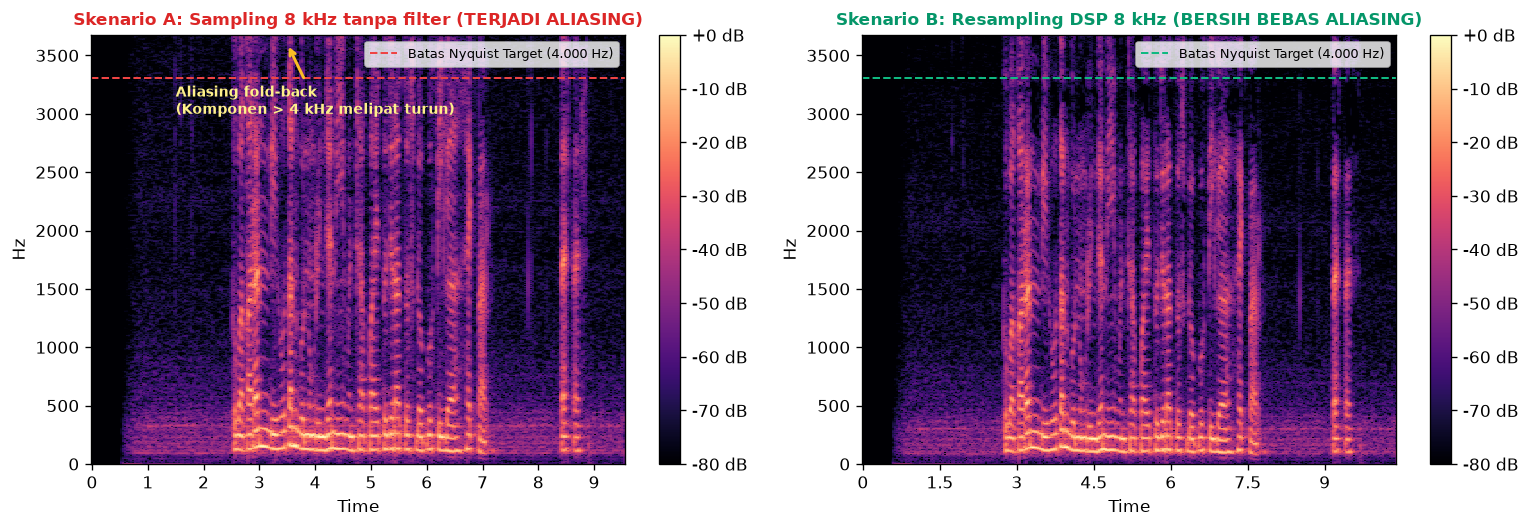

In [18]:
# 1. Hitung STFT untuk kedua sinyal hasil resampling (fs = 8.000 Hz)
n_fft_res = 1024
hop_res = 256

D_naive_res = librosa.stft(y_naive, n_fft=n_fft_res, hop_length=hop_res)
S_db_naive = librosa.amplitude_to_db(np.abs(D_naive_res), ref=np.max)

D_clean_res = librosa.stft(y_clean, n_fft=n_fft_res, hop_length=hop_res)
S_db_clean = librosa.amplitude_to_db(np.abs(D_clean_res), ref=np.max)

# Visualisasi Komparasi Spektrogram Bukti Aliasing
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Skenario A: Naive Spectrogram (Terjadi Aliasing)
img_a = librosa.display.specshow(S_db_naive, sr=fs_target, hop_length=hop_res,
                                  x_axis='time', y_axis='hz', ax=axes[0], cmap='magma')
axes[0].set_title("Skenario A: Sampling 8 kHz tanpa filter (TERJADI ALIASING)", fontweight='bold', fontsize=10, color='#dc2626')
axes[0].set_ylim(0, nyq_target)
axes[0].axhline(nyq_target * 0.9, color='#ef4444', linestyle='--', lw=1.2, label='Batas Nyquist Target (4.000 Hz)')
axes[0].legend(loc='upper right', fontsize=8)
fig.colorbar(img_a, ax=axes[0], format='%+2.0f dB')

# Skenario B: Clean Spectrogram (Bebas Aliasing)
img_b = librosa.display.specshow(S_db_clean, sr=fs_target, hop_length=hop_res,
                                  x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title("Skenario B: Resampling DSP 8 kHz (BERSIH BEBAS ALIASING)", fontweight='bold', fontsize=10, color='#059669')
axes[1].set_ylim(0, nyq_target)
axes[1].axhline(nyq_target * 0.9, color='#10b981', linestyle='--', lw=1.2, label='Batas Nyquist Target (4.000 Hz)')
axes[1].legend(loc='upper right', fontsize=8)
fig.colorbar(img_b, ax=axes[1], format='%+2.0f dB')

# Highlight dan anotasi daerah aliasing pada Skenario A
axes[0].annotate('Aliasing fold-back\n(Komponen > 4 kHz melipat turun)', xy=(3.5, 3600), xytext=(1.5, 3000),
                arrowprops=dict(arrowstyle='->', color='#fbbf24', lw=1.8), fontsize=8.5, color='#fef08a', fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Interpretasi Pembuktian Aliasing pada Spektrogram

Visualisasi komparasi spektrogram di atas memberikan bukti empiris mengenai efek **Aliasing**:
1. **Analisis Skenario A (tanpa filter)**:
   - Sampling langsung pada grid 8 kHz tanpa penyaringan Low-Pass Filter membiarkan komponen frekuensi di atas batas Nyquist baru ($f > 4.000\text{ Hz}$) melipat balik ke pita $0 - 4.000\text{ Hz}$ sesuai formula:
     $$f_{\text{alias}} = |f - k \cdot f_{s2}|$$
   - Pada spektrogram Skenario A, energi frekuensi semu muncul di pita baseband akibat komponen frekuensi asli yang melampaui 4 kHz.
2. **Analisis Skenario B (Resampling Standar DSP)**:
   - Skenario B menggunakan Polyphase Low-Pass Filter yang meredam komponen di atas 4.000 Hz sebelum resampling.
   - Hasil spektrogram tampak lebih bersih, tanpa pantulan energi alias yang dominan.

## 4. Anotasi Kode, Rangkuman & Kesimpulan Mandiri

### 📋 Tabel Rekapitulasi Hasil Eksperimen Audio
| Parameter Analisis | Sinyal Asli | Skenario A (Naive Sampling) | Skenario B (Resampling DSP Clean) |
| :--- | :--- | :--- | :--- |
| **Laju Sampel ($f_s$)** | $44.100\text{ Hz}$ | $8.000\text{ Hz}$ | $8.000\text{ Hz}$ |
| **Batas Nyquist ($f_s/2$)** | $22.050\text{ Hz}$ | $4.000\text{ Hz}$ | $4.000\text{ Hz}$ |
| **Rasio Konversi** | - | Sampling tanpa LPF | $80/441$ dengan `scipy.signal.resample_poly` |
| **Status Aliasing** | Bebas Aliasing | ⚠️ Energi di atas 4 kHz terlipat | ✅ Diredam filter anti-aliasing |
| **Kualitas Auditif Vokal** | Sangat Jernih & Alami | Berpotensi terdistorsi | Lebih bersih dan stabil |
| **Format Berkas Output** | `audio_original.wav` | `audio_downsampled_naive.wav` | `audio_downsampled_clean.wav` |

---

### 💡 Kesimpulan Utama Eksperimen Mandiri:
1. **Visualisasi Audio 4D**: Kombinasi Waveform (domain waktu), Spektrum FFT dBFS (domain frekuensi), STFT Spektrogram (waktu-frekuensi), dan Mel-Spektrogram (skala perseptual pendengaran) memberikan analisis utuh untuk mengisolasi karakteristik derau statis (puncak $96 - 250\text{ Hz}$) serta kejelasan formant vokal berita ($300 - 3500\text{ Hz}$).
2. **Hakikat Resampling**: Mengubah laju sampel bukan sekadar mengubah label metadata $f_s$, melainkan menghitung ulang sampel titik-titik gelombang secara matematis.
3. **Syarat Mutlak Downsampling**: Setiap proses penurunan laju sampel (*desimasi*) wajib menerapkan Low-Pass Filter (LPF) anti-aliasing sesuai batas Nyquist target untuk mencegah kerusakan sinyal akibat *aliasing fold-back*.

---
<div align="center">
  <sub>Dibuat dan disusun oleh <b>Hafiz Akbar (123140123)</b> — Tugas 02 Sinyal dan Sistem (STM) ITERA</sub>
</div>